<img src="https://www.thegeniuschoice.com/wp-content/uploads/2017/10/Logo-DUOC-transparente.png" width="300" alt="DuocUC"/>

#   **Desarrollo de la evaluación 2** 🍽️
### **Sección 301D – Programación para la ciencia de datos**
**Ingeniería en Informática –  Programación para la ciencia de datos** | Google Colab
| Campo | Detalle |
|---|---|
| **Asignatura** | Preprocesamiento de Datos |
| **Escuela** | Ingeniería en Informática · Mención Ciencia de Datos |
| **Profesora** | Karla Marilyn Roco Ramirez |
| **Integrante 1** | Diego Marambio Cuevas |
| **Integrante 2** |Sebastian Ignacio Alvarez Cisterna|
| **Integrante 3** | Erick Rosales Parra |
---


##**En esta primera seccion solo se realizara la carga del data set y la configuración del entorno**

In [1]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/googleplaystore_clean.csv")

size_median = df['Size'].median()
df['Size'].fillna(size_median, inplace=True)

size_scaled_median = df['Size_Scaled'].median()
df['Size_Scaled'].fillna(size_scaled_median, inplace=True)

df.head(3)

/tmp/ipykernel_8486/884230450.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Size'].fillna(size_median, inplace=True)
/tmp/ipykernel_8486/884230450.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Scaled
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,0.0,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,-0.101485
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,0.0,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,-0.323320
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,0.0,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,-0.558465


--- Resumen del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10357 entries, 0 to 10356
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  object 
 1   Category        10357 non-null  object 
 2   Rating          10357 non-null  float64
 3   Reviews         10357 non-null  int64  
 4   Size            10357 non-null  float64
 5   Installs        10357 non-null  int64  
 6   Type            10357 non-null  float64
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10357 non-null  object 
 10  Last Updated    10357 non-null  object 
 11  Current Ver     10357 non-null  object 
 12  Android Ver     10357 non-null  object 
 13  Size_Scaled     10357 non-null  float64
 14  Is_High_Rated   10357 non-null  int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 1.2+ MB
None


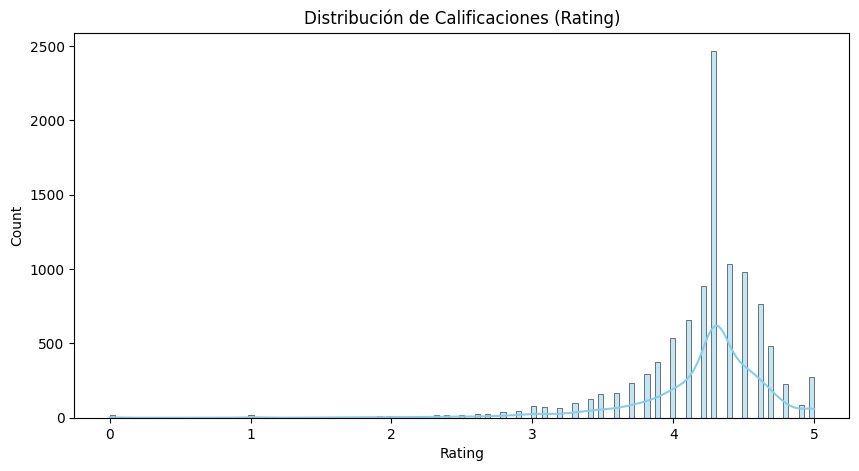

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.impute import SimpleImputer


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


for path in ['models/trained_models', 'results/plots', 'results/metrics']:
    os.makedirs(path, exist_ok=True)

# Definimos "Éxito" como Rating >= 4.2 para tener un problema de clasificación binaria
df['Is_High_Rated'] = (df['Rating'] >= 4.2).astype(int)


print("--- Resumen del Dataset ---")
print(df.info())

plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], kde=True, color='skyblue')
plt.title('Distribución de Calificaciones (Rating)')
plt.savefig('results/plots/rating_distribution.png')
plt.show()

In [ ]:
df["Category"].value_counts()

,count
Category,
FAMILY,1943
GAME,1121
TOOLS,843
BUSINESS,427
MEDICAL,408
PRODUCTIVITY,407
PERSONALIZATION,388
LIFESTYLE,373
COMMUNICATION,366


In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


Con todo listo para trabjaar comenzaremos a realizar los modelos solicitados

##**1°MODELO NO SUPERVISADO**

El los siguientes bloques de código en los cuales implementaremos un modelo no supervisado para segmentar automáticamente las aplicaciones en tres grupos (clusters)

Para lograrlo, primero seleccionaremos variables numéricas clave (reseñas, tamaño, instalaciones y precio) y las pasaremos por un pipeline que rellena los datos faltantes, normaliza las escalas numéricas y reduce la información a solo dos dimensiones utilizando PCA (Análisis de Componentes Principales)

In [ ]:
features_unsupervised = ['Reviews', 'Size', 'Installs', 'Price']
X_unsup = df[features_unsupervised]

unsup_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=RANDOM_STATE))
])



A continuación y para finalizar con este modelo no supervisado, aplicaremos el algoritmo K-Means para agrupar las apps según sus similitudes, evalúaremos la calidad matemática de estos grupos con la métrica Silhouette Score y generaremos un gráfico de dispersión para visualizar claramente los segmentos descubiertos.


Silhouette Score (K-Means): 0.9285


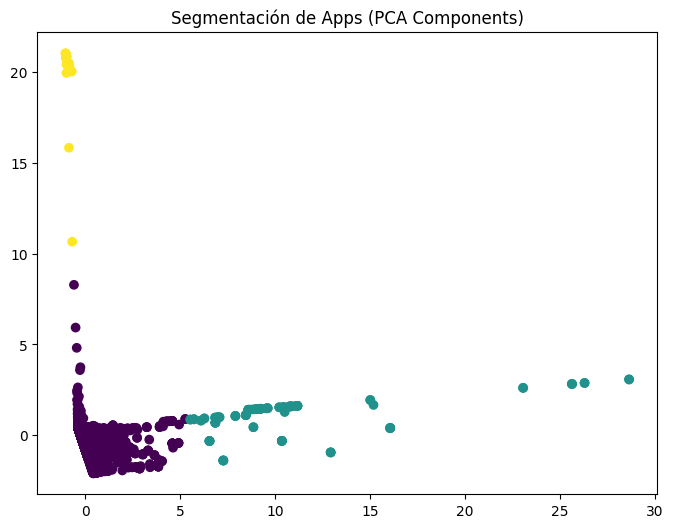

In [ ]:
X_pca = unsup_pipe.fit_transform(X_unsup)
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(X_pca)


print(f"\nSilhouette Score (K-Means): {silhouette_score(X_pca, kmeans.labels_):.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title('Segmentación de Apps (PCA Components)')
plt.savefig('results/plots/app_clusters.png')
plt.show()

## **2°Modelos Supervisados**

  En esta sección, realizaremos los modelos supervisados donde el objetivo es predecir si una aplicación tendrá "Éxito" (indicado por un rating igual o superior a 4.2).

Para lograr cumplir con las buenas prácticas y evitar la fuga de datos (Data Leakage), utilizaremos un ColumnTransformer dentro de un Pipeline. Esto nos permite realizar el preprocesamiento de manera ordenada:

* 1°**Variables Numéricas:** Se imputan los valores nulos con la media y se escalan mediante StandardScaler.

* 2°**Variables Categóricas:** Se transforman utilizando OneHotEncoder.

Para esto implementaremos 2 modelos:
* **Regresión Logística:** Servirá como nuestro modelo base.
* **Random Forest Classifier:** Este sera un modelo mas avanzado basado en un arbol de deciciones.

Partiremos definiendo las variables y separando el conjunto de entrenamiento y de pruebas

In [ ]:
# Definimos las variables
categorical_cols = ['Category', 'Type', 'Content Rating']
numerical_cols = ['Reviews', 'Size', 'Installs', 'Price']

X = df[categorical_cols + numerical_cols]
y = df['Is_High_Rated']

# Sepración del conjunto de entrenamiento y pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

Ahora transformaremos las columnas para que el modelo las pueda trabajar de forma correcta y realizaremos 2 pipelines uno para el modelo de regresion logistica y el otro para el modelo basado en un arbol de deciciones

In [ ]:
# Transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Pipeline 1: Logistic Regression (Modelo Base)
pipe_lr = Pipeline([
    ('prepro', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Pipeline 2: Random Forest (Modelo Avanzado)
pipe_rf = Pipeline([
    ('prepro', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
])

## **3° Evaluación Comparativa de Modelos**

Antes de evaluar con los datos de prueba (test), es crucial realizar una **Validación Cruzada** (cross_val_score) sobre los datos de entrenamiento para obtener un rendimiento promedio aceptable y asegurarnos de que el modelo no se esté sobreajustando.

Se evaluará utilizando la métrica F1-Score, ya que al tratarse de clasificación, nos interesa encontrar un balance correcto entre la Precisión (no dar falsos positivos) y el Recall (encontrar la mayor cantidad de apps exitosas posibles).

In [ ]:


print("\n--- Validación Cruzada ---")
for name, pipe in [('Regresión Logística', pipe_lr), ('Random Forest', pipe_rf)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    print(f"{name} - F1-Score Promedio: {scores.mean():.4f}")


--- Validación Cruzada ---
Regresión Logística - F1-Score Promedio: 0.8205
Random Forest - F1-Score Promedio: 0.8058


Uso de F1-Score frente a Accuracy

Para evaluar nuestros modelos supervisados, hemos decidido utilizar **F1-Score** en lugar de la tradicional Exactitud (Accuracy). Esta decisión se fundamenta en la naturaleza de nuestros datos y en el objetivo del negocio:

1. **Desbalance de Clases:** En la Google Play Store, la gran mayoría de las aplicaciones tienen calificaciones relativamente altas (el promedio ronda el 4.1 o 4.2). Si usáramos Accuracy, un modelo "perezoso" que predijera que *todas* las apps son un "Éxito" obtendría un porcentaje de acierto muy alto engañosamente, sin estar aprendiendo realmente a distinguir.
2. **Compemsacion entre Precisión y Exhaustividad:** El F1-Score es la media armónica entre Precision (las apps que predice exitosas) y Recall (de todas las apps verdaderamente exitosas ¿cuántas logró encontrar mi modelo?).

El haber elejido el F1-Score es muy importe, ya que, de lo contrario se podria desechar una app que puede ser exitosa o el caso contrario, se puede añadir una app que sea un fracaso

## **4° Optimización de Hiperparámetros**

Una vez comparado el modelo base contra el Random Forest, procederemos a aumentar el rendimiento de este último mediante **GridSearchCV**.GridSearchCV prueba exhaustivamente todas las combinaciones posibles de los hiperparámetros que definamos (como la profundidad del árbol y el número de estimadores) buscando la configuración que entregue la mejor precisión.

In [ ]:

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5]
}

print("\nIniciando GridSearchCV para Random Forest (Puede tardar unos minutos)...")
grid_search = GridSearchCV(pipe_rf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Mejores Hiperparámetros encontrados: {grid_search.best_params_}")


Iniciando GridSearchCV para Random Forest (Puede tardar unos minutos)...
Mejores Hiperparámetros encontrados: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}


## **5° Análisis Final y Serialización**

Para finalizar con el trabajo solicitado, utilizaremos el mejor modelo encontrado por la optimización y lo probaremos con nuestro conjunto de pruebas (X_test). Luego generaremos el reporte de clasificación para ver las metricas de la precición


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Reporte de Clasificación Final ---")
print(classification_report(y_test, y_pred))


--- Reporte de Clasificación Final ---
              precision    recall  f1-score   support

           0       0.58      0.41      0.48       643
           1       0.77      0.87      0.81      1429

    accuracy                           0.72      2072
   macro avg       0.67      0.64      0.65      2072
weighted avg       0.71      0.72      0.71      2072




Ahora que el mejor modelo encontrado por el **GridSearchCV** Generaremos la **Matriz de Confusión** para visualizar especificamente dónde el modelo acierta (diagonal de izquierda a derecha, arriba hacia abajo) y dónde comete los errores de falsos positivos o falsos negativos.

Tras confirmar el éxito, exportamos el modelo final garantizando la reproductibilidad del proyecto.

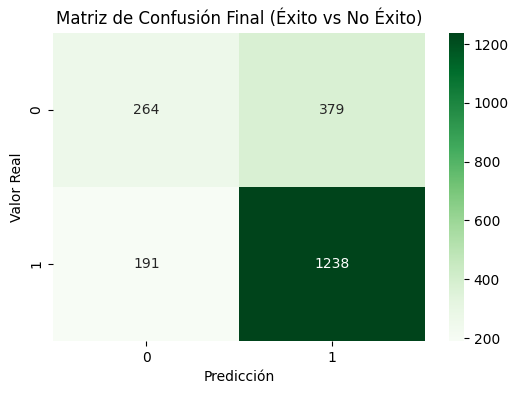


[ÉXITO] Modelo guardado en 'models/trained_models/google_play_model_v1.joblib'. El proceso es 100% reproducible.


In [ ]:
# Guardar matriz de confusión
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión Final (Éxito vs No Éxito)')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.savefig('results/plots/final_confusion_matrix.png')
plt.show()

# Serialización del modelo
joblib.dump(best_model, 'models/trained_models/google_play_model_v1.joblib')
print("\n[ÉXITO] Modelo guardado en 'models/trained_models/google_play_model_v1.joblib'. El proceso es 100% reproducible.")